# Zeitlin model with constraints

This notebook is a demonstration of how to use `quflow.constraints' module

In [1]:
# For non-interactive plots:
%matplotlib inline

# Looks better on macbooks
%config InlineBackend.figure_format = 'retina' 

import numpy as np
import quflow as qf

In [2]:

# Modules to load
import matplotlib.pyplot as plt
from quflow.constraints import *

# Save cell for runfile 
cell1 = In[-1]

##### Define the functions defining the islands, the level sets, and the circulations

In [3]:
N= 128

f1 = qf.dynamics.blob(N, [0, 2, 1],0.4) # Island 1 
f2 = qf.dynamics.blob(N, [0, -2, -1],0.4) # Island 2
functions = [f1,f2]
level_sets = [0.0150,0.015]  # Choose coastlines
circulations= [17,0] # Choose "circulaitons"cell2 = In[-1]

# Save cell for runfile
cell2 = In[-1]

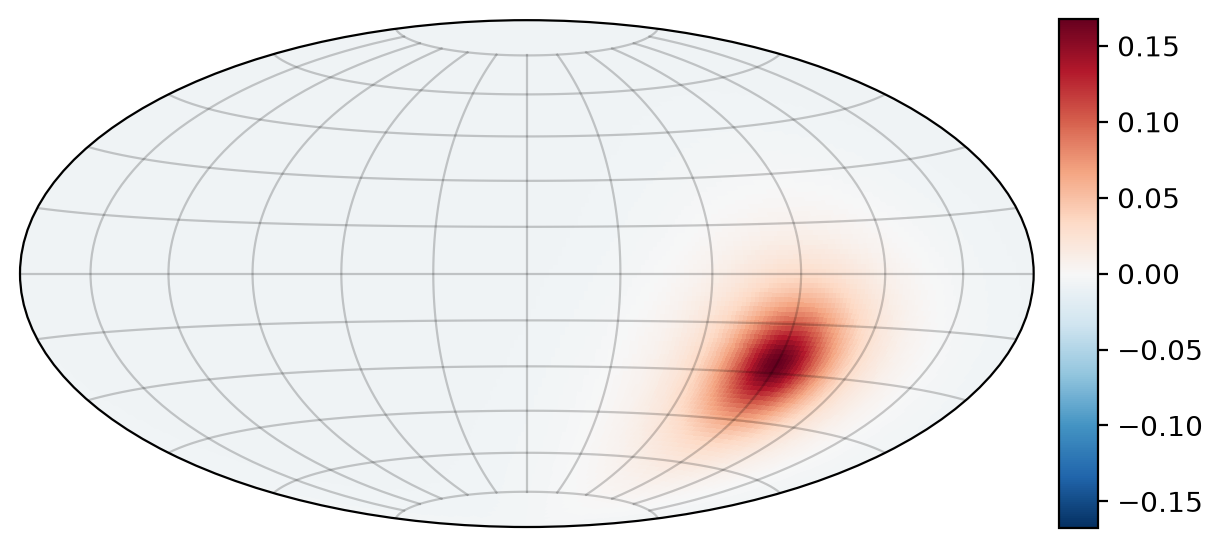

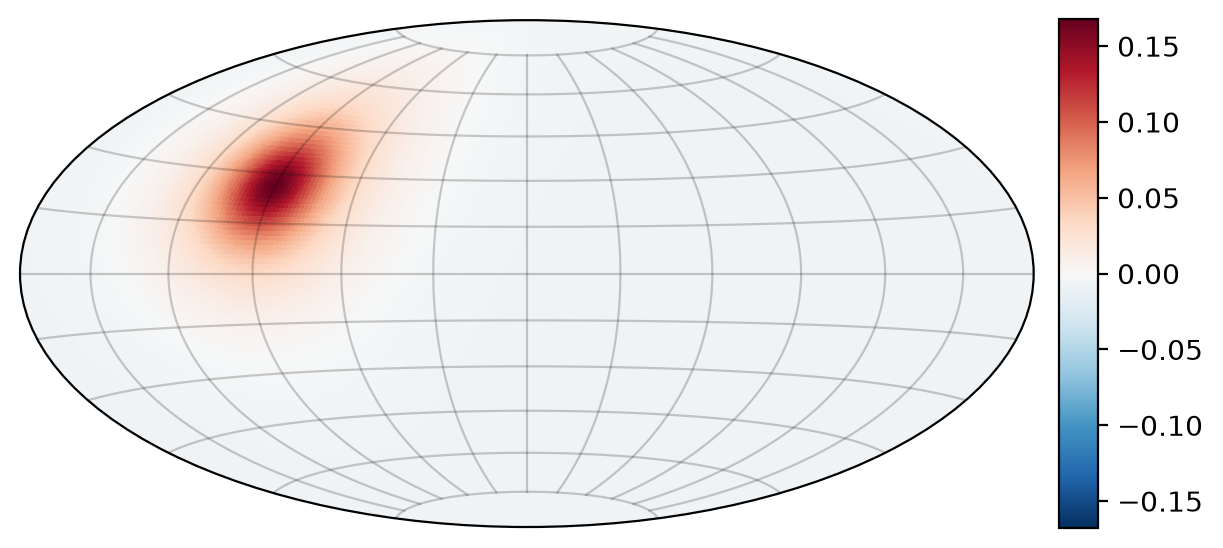

In [4]:
qf.plot(f1, colorbar=True)
qf.plot(f2,colorbar=True)

##### Make the projection into the space of functions that are zero on each island, except for the circulation term. Then add a plotter for functions in the range.

In [5]:

# Make the projection, which makes the initial vorticity zero on the islands exepct for circulation terms, and sets trace to zero. 
projector = trace_free_block_projector(functions, level_sets, circulations,only_highest=True)
circulations_term = projector(qf.shr2mat(np.zeros(N**2)))
# Make plotter with contours
constraint_animation_args = [functions, level_sets,circulations_term]
cplot = plotter(functions, level_sets, circulations_term, N=N)

# Save cell for runfile
cell3 = In[-1]

##### Make some inital vorticity, and project it with the projection.

In [6]:
# Make initial data
omega0 = qf.analysis.random_shr(lmax=11, s=0.0, gamma=0., seed=42)
W0 = qf.shr2mat(omega0, N=N) 

# Project the initial vorticity
W0_proj = projector(W0)


# Save cell for runfile
cell4 = In[-1]

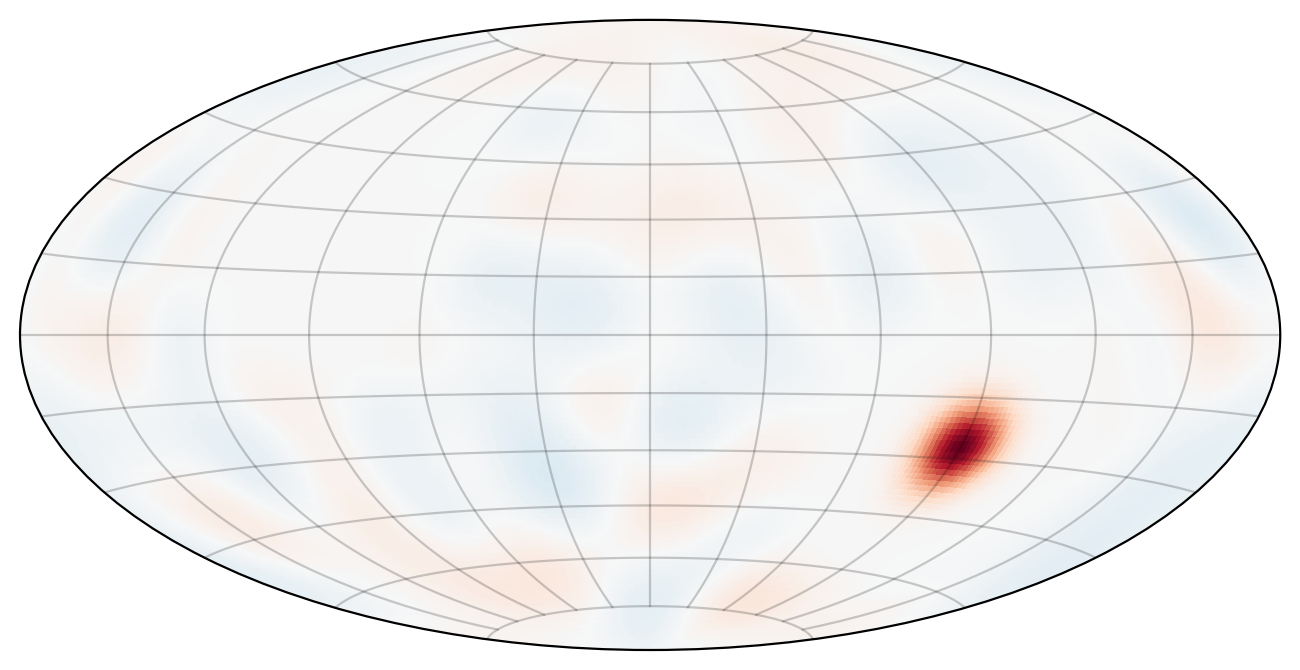

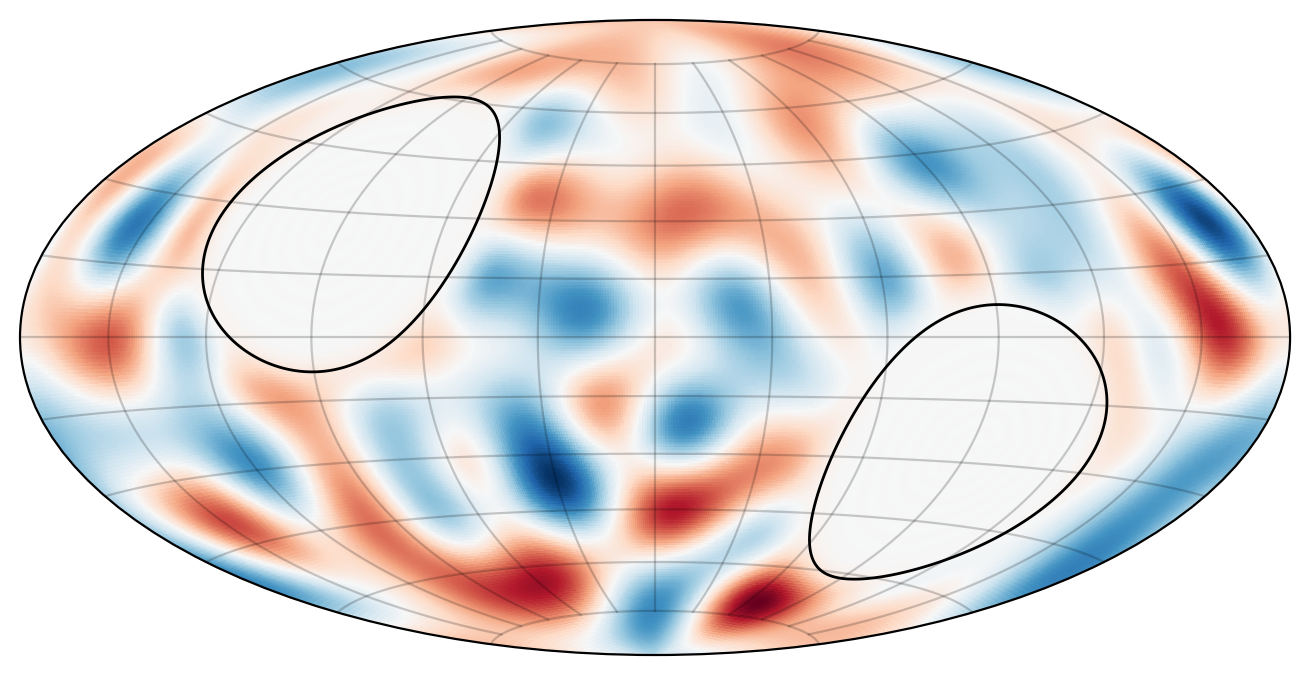

In [7]:
qf.plot(W0_proj)
cplot(W0_proj) # Better plot for projected vorticities, and has contours.

##### Make the constraint function $F_c$. 

In [8]:
Fc = constraint_matrix(functions,level_sets) # Construct the constraint matrix

# Save cell for runfile
cell5 = In[-1]

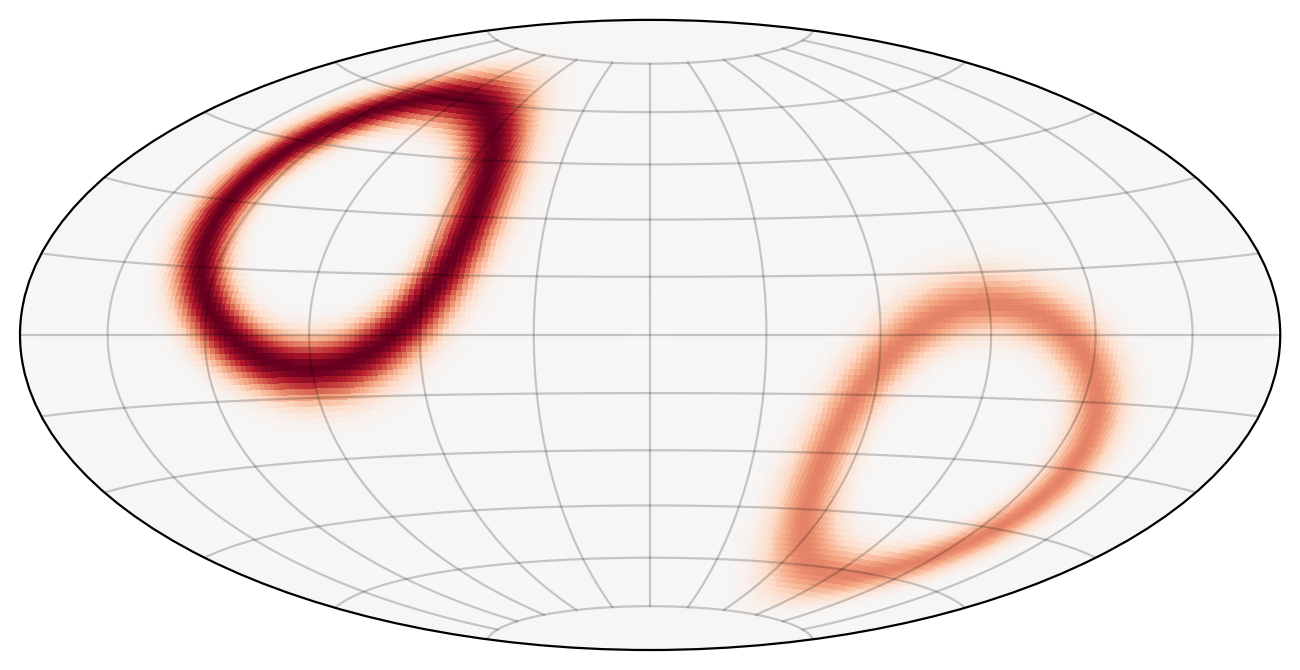

In [9]:
qf.plot(Fc)

##### Make the constraint solver

In [10]:
# This can take a long time for large N
solver = CommutatorPoissonSolver(
  Fc, num_active_eigenvalues = len(functions),  rng=np.random.default_rng(seed=42))

CommutatorPoissonSolver: retained 506 constraint rows.


The cell above can be done only on a cluster instead.

In [11]:
cell6 = "solver = CommutatorPoissonSolver( Fc, num_active_eigenvalues = len(functions),  rng=np.random.default_rng(seed=42))"

##### Add logger functions

In [12]:
# For example, define logger functions
# (exactly these loggers are also defined in `qf.physics.energy_euler` and `qf.physics.enstrophy`)
def energy(W):
    P = qf.solve_poisson(W)
    return -qf.geometry.inner_L2(W, P)

def enstrophy(W):
    return qf.geometry.inner_L2(W, W)

# For example, define a new Poisson solver here:
def solve_poisson_special(W):
    raise NotImplementedError()

# Save cell for runfile
cell7 = In[-1]

##### Make simulation object

In [13]:
# Simulation
filename = "constraint_sim_N_{}.hdf5".format(N)
simtime = 10
inner_time = 0.2
dt = 0.25 * qf.hbar(N)

# Callback data object
mysim = qf.QuSimulation(filename, overwrite=True, state=W0_proj, 
                        loggers={'energy':qf.physics.energy_euler, 'enstrophy':qf.physics.enstrophy})

# Set parameters for `solve` function. This is VERY convenient when moving a 
# simulation from your computer to the cluster.
mysim['dt'] = dt
mysim['simtime'] = simtime
mysim['inner_time'] = inner_time
mysim['integrator'] = qf.isomp
#mysim['hamiltonian'] = constraints_solver.solve

In [14]:
cells =[cell1,cell2,cell3,cell4,cell5,cell6,cell7]

prerun =""

for cell in cells:
    prerun += "\n" + cell

# Short code which deletes lines that contain cell fro prerun
prerun= "\n".join([line for line in prerun.splitlines() if "cell" not in line])

mysim["prerun"] = prerun

##### Make scripts to run on Orion HPC

In [15]:
qf.create_runfile(mysim, runfilename="mysim_runfile.py")

In [16]:
%%writefile run_orion.sh
#!/bin/bash
#SBATCH --mem=64G
#SBATCH --partition=orion
#SBATCH -t 7-00:00:00 # maximum simulation time is 7 days
#SBATCH -J quflow-sim # name of job
#SBATCH -n 1 # number of tasks to run
#SBATCH -c 4 # number of cores per task
#SBATCH -N 1 # use maximum 1 node
#SBATCH --mail-user=andreas.myklebust@nmbu.no
#SBATCH --mail-type=END,FAIL
#SBATCH --account=realtek_stipandreasmyklebust




echo "=== Ran on $(hostname) at $(date) ==="
echo "CPU cores visible: $(nproc)"
free -h

# Run script for starting simulations on Vera

basedir=$(dirname "$0")
if command -v module &> /dev/null
then
    # if [[ $SLURM_NTASKS =~ ^[0-9]+$ ]]; then
    #     export OMP_NUM_THREADS=$((SLURM_NTASKS*SLURM_CPUS_PER_TASK))
    # fi
    echo "Max number of threads: $OMP_NUM_THREADS"

    echo "Loading modules ..."

    # Current 
    module load FlexiBLAS/3.4.5-GCC-14.3.0
    module load SciPy-bundle/2025.07-gfbf-2025b
    module load FFmpeg/7.1.2-GCCcore-14.3.0
    module load FFTW/3.3.10-GCC-14.3.0
    module load tqdm/4.67.1-GCCcore-14.3.0
    module load matplotlib/3.10.5-gfbf-2025b
    module load virtualenv/20.32.0-GCCcore-14.3.0
    module load numba/0.62.0-foss-2025b
    module load h5py/3.14.0-foss-2025b


    if [ -d ${HOME}/quflow-addons ]; then 
        echo "Environment ~/quflow-addons exists, activating it ..."
        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate
        echo "...done"
    else
        # Create virtualenv. You can change "quflow-addons-amd" to some other name
        # if you need to keep several environments.
        echo "Creating virtual environment ~/quflow-addons ..." 
        virtualenv --system-site-packages ${HOME}/quflow-addons
        echo "...done"

        # Load virtualenv
        source ${HOME}/quflow-addons/bin/activate

        # Install quflow as an editable module (located in the home folder)
        if [ -d ${HOME}/quflow ]; then
            echo "Local quflow directory ~/quflow exists"

            # Install quflow to the virtualenv
            echo "Pip-installing editable quflow into ~/quflow-addons ..."
            pip install -e ${HOME}/quflow
            echo "...done"

        else
            # Install non-editable (regular) quflow
            echo "Pip-installing non-editable quflow into ~/quflow-addons ..."
            pip install https://github.com/andrmykl/quflow/archive/master.zip
            echo "...done"
        fi
    fi
fi

echo "Running command: python -u $@"
start=`date +%s`
python -u "$@"
end=`date +%s`
runtime=$((end-start))
echo "...finished in $runtime seconds"

Overwriting run_orion.sh


##### Run the simulation on the computer

  0%|          | 0/2560 [00:00<?, ? steps/s]

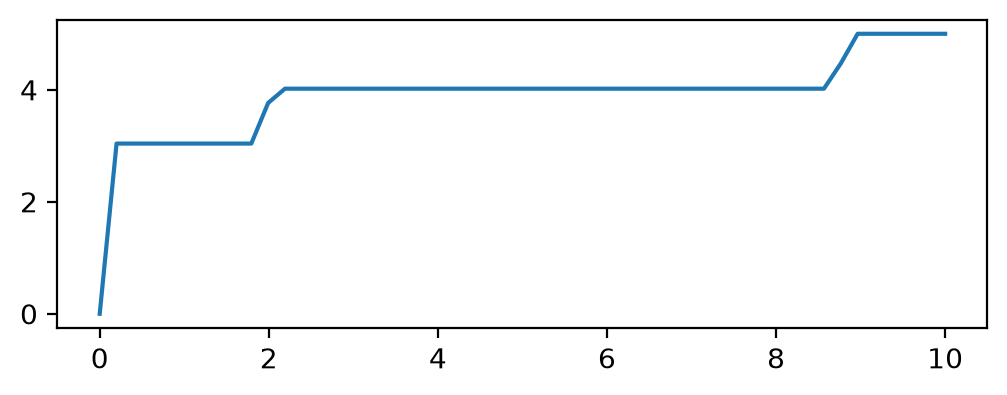

In [17]:
import numba

numba.set_num_threads(1) # Find out what is fastest on your computer

# Run simulation directly from QuSimulation object
qf.solve(mysim,hamiltonian=solver.solve)

# Plot average number of iterations over time.
# This is a good check that everything went well 
# (you should select the time-step so that you 
# never hit `maxit` which defaults to 10).
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    plt.plot(mysim['time'], mysim['iterations'])

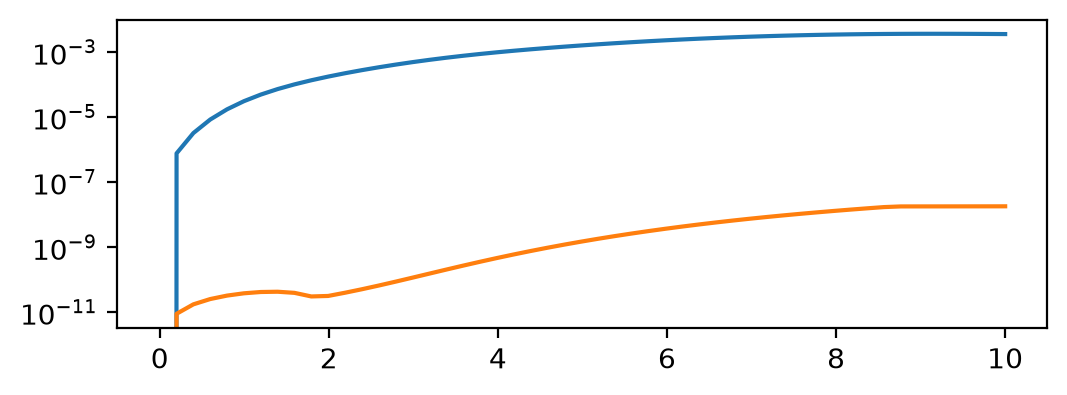

In [18]:
# Plot energy and enstrophy
with plt.rc_context({'figure.figsize':(6,2)}), qf.QuSimulation(filename) as mysim:
    # plt.plot(mysim['time'], mysim['enstrophy'])
    E = mysim['energy']
    Q = mysim['enstrophy']
    t = mysim['time']
    plt.semilogy(t, np.abs(E-E[0]))
    plt.semilogy(t, np.abs(Q-Q[0]))

##### Make video of simulation

In [19]:
qf.create_animation(filename.replace(".hdf5", ".mp4"), mysim['mat'],constraint_animation_args=constraint_animation_args)

  0%|          | 0/52 [00:00<?, ? frames/s]

100%|██████████| 52/52 [00:03<00:00, 13.98 frames/s]
